In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

conn = sqlite3.connect("../data/vayu_clean.db")
df = pd.read_sql("SELECT * FROM features", conn, parse_dates=["timestamp"])
conn.close()

print(df.shape)
df.info()
df.head()

(59961, 27)
<class 'pandas.DataFrame'>
RangeIndex: 59961 entries, 0 to 59960
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 59961 non-null  int64         
 1   city               59961 non-null  str           
 2   latitude           59961 non-null  float64       
 3   longitude          59961 non-null  float64       
 4   aqi                59961 non-null  int64         
 5   pm25               59961 non-null  float64       
 6   pm10               59961 non-null  float64       
 7   no2                59961 non-null  float64       
 8   o3                 59961 non-null  float64       
 9   timestamp          59961 non-null  datetime64[us]
 10  fetched_at         59961 non-null  str           
 11  temperature_c      59961 non-null  float64       
 12  humidity_pct       59961 non-null  float64       
 13  wind_speed_ms      59961 non-null  float64       
 14  wind_

,id,city,latitude,longitude,aqi,pm25,pm10,no2,o3,timestamp,...,day_of_week,month,is_weekend,aqi_lag_1h,aqi_lag_3h,aqi_lag_24h,aqi_roll_6h,aqi_roll_24h,next_aqi,next_aqi_category
0,1,Ahmedabad,23.0225,72.5714,3,38.56,71.55,4.02,67.57,2026-01-02 01:00:00,...,4,1,0,NaN,NaN,NaN,3.0,3.0,4.0,Poor
1,2,Ahmedabad,23.0225,72.5714,3,39.89,72.73,5.78,62.76,2026-01-02 02:00:00,...,4,1,0,3.0,NaN,NaN,3.0,3.0,4.0,Poor
2,3,Ahmedabad,23.0225,72.5714,3,40.94,73.76,7.91,57.71,2026-01-02 03:00:00,...,4,1,0,3.0,NaN,NaN,3.0,3.0,4.0,Poor
3,4,Ahmedabad,23.0225,72.5714,3,41.27,73.48,8.28,56.08,2026-01-02 04:00:00,...,4,1,0,3.0,3.0,NaN,3.0,3.0,4.0,Poor
4,5,Ahmedabad,23.0225,72.5714,3,41.30,72.20,8.13,59.40,2026-01-02 05:00:00,...,4,1,0,3.0,3.0,NaN,3.0,3.0,4.0,Poor


In [2]:
df.describe()[["aqi", "pm25", "pm10", "no2", "o3", "temperature_c", "wind_speed_ms"]]

,aqi,pm25,pm10,no2,o3,temperature_c,wind_speed_ms
count,59961.000000,59961.000000,59961.000000,59961.000000,59961.000000,59961.000000,59961.000000
mean,3.294058,56.589212,73.304138,5.760206,82.700474,25.873067,2.313877
min,1.000000,0.000000,0.000000,0.030000,0.010000,3.200000,0.000000
25%,2.000000,19.740000,31.800000,1.670000,48.760000,21.400000,1.410000
50%,3.000000,37.090000,59.310000,4.140000,77.450000,26.500000,2.200000
75%,4.000000,73.660000,94.420000,8.180000,110.830000,30.700000,3.080000
max,5.000000,675.850000,684.660000,58.830000,280.930000,44.000000,12.270000
std,1.277735,60.236181,63.542391,5.593303,43.226671,6.977686,1.191030


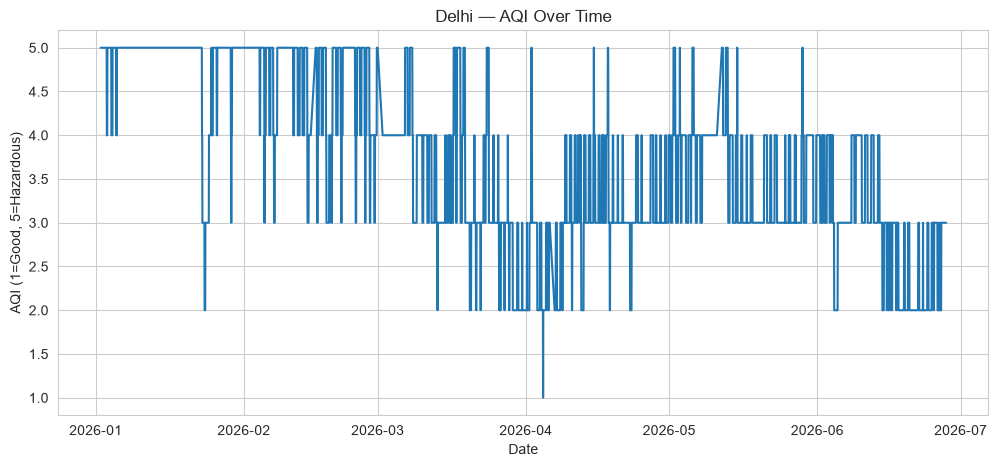

In [3]:
delhi = df[df["city"] == "Delhi"].sort_values("timestamp")

plt.plot(delhi["timestamp"], delhi["aqi"])
plt.title("Delhi — AQI Over Time")
plt.xlabel("Date")
plt.ylabel("AQI (1=Good, 5=Hazardous)")
plt.show()

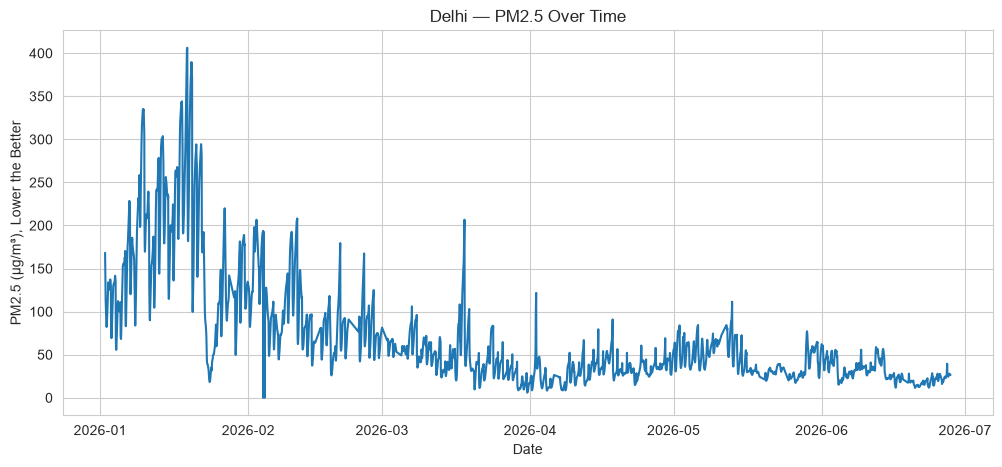

In [4]:
delhi = df[df["city"] == "Delhi"].sort_values("timestamp")

plt.plot(delhi["timestamp"], delhi["pm25"])
plt.title("Delhi — PM2.5 Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³), Lower the Better")
plt.show()

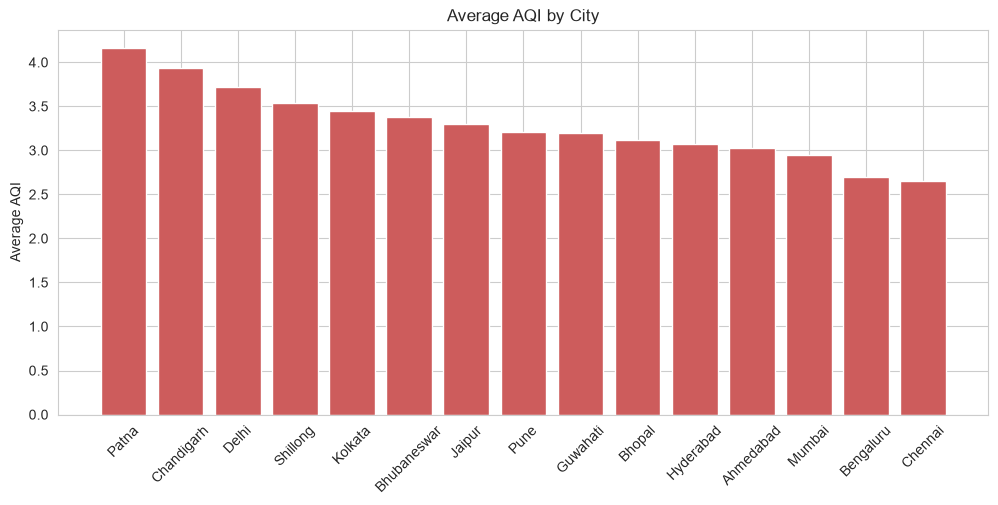

city
Patna          4.163696
Chandigarh     3.934723
Delhi          3.722320
Shillong       3.539057
Kolkata        3.451460
Bhubaneswar    3.382877
Jaipur         3.297263
Pune           3.213595
Guwahati       3.202146
Bhopal         3.116746
Hyderabad      3.071805
Ahmedabad      3.027785
Mumbai         2.951377
Bengaluru      2.695456
Chennai        2.647000
Name: aqi, dtype: float64

In [5]:
city_avg = df.groupby("city")["aqi"].mean().sort_values(ascending=False)

plt.bar(city_avg.index, city_avg.values, color="indianred")
plt.title("Average AQI by City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.show()

city_avg

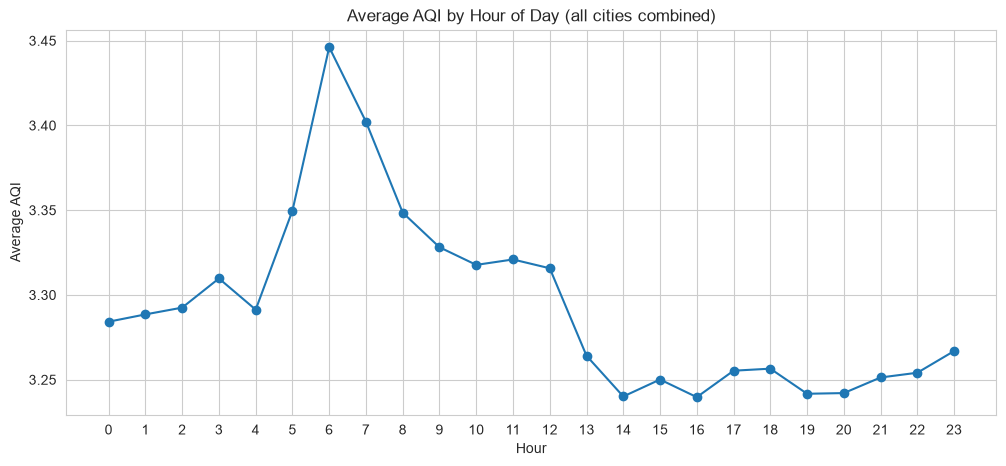

In [6]:
hourly_avg = df.groupby("hour")["aqi"].mean()

plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.title("Average AQI by Hour of Day (all cities combined)")
plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.xticks(range(0, 24))
plt.show()

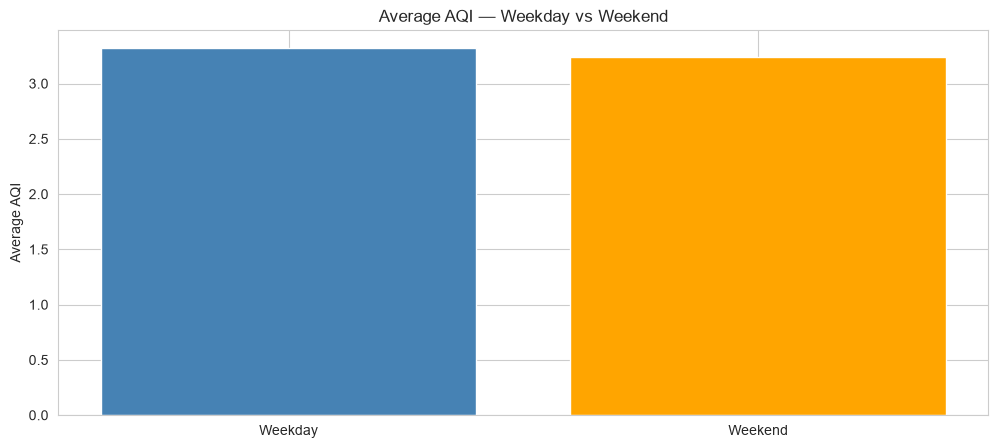

In [7]:
weekend_avg = df.groupby("is_weekend")["aqi"].mean()
weekend_avg.index = ["Weekday", "Weekend"]

plt.bar(weekend_avg.index, weekend_avg.values, color=["steelblue", "orange"])
plt.title("Average AQI — Weekday vs Weekend")
plt.ylabel("Average AQI")
plt.show()

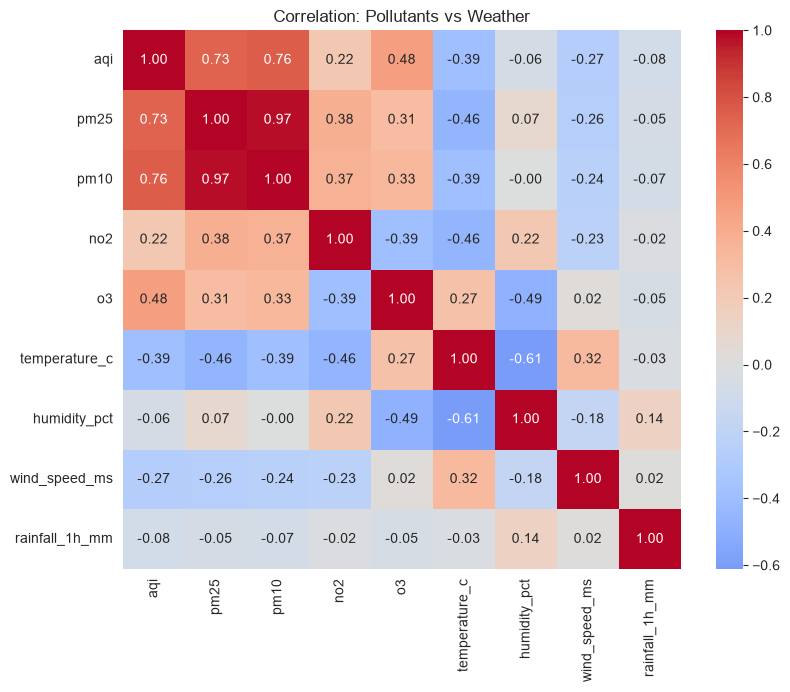

In [8]:
corr_cols = ["aqi", "pm25", "pm10", "no2", "o3",
             "temperature_c", "humidity_pct", "wind_speed_ms", "rainfall_1h_mm"]

corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation: Pollutants vs Weather")
plt.show()

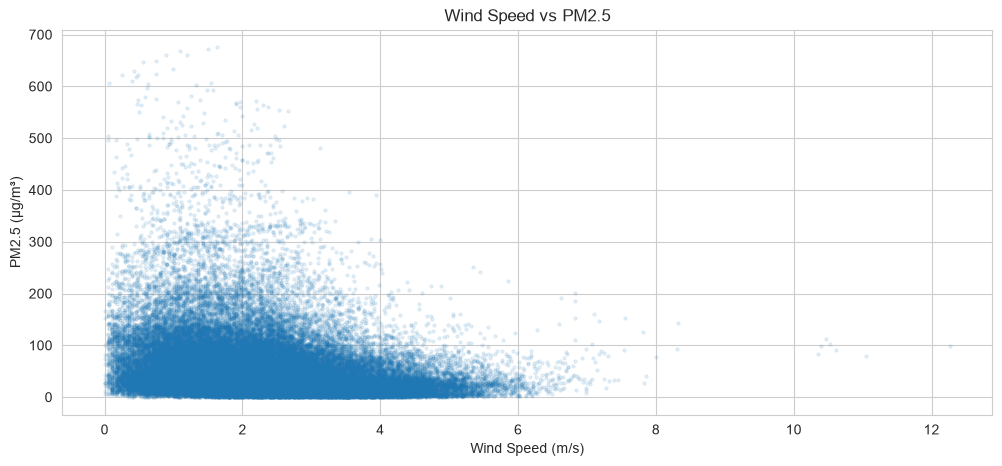

In [9]:
plt.scatter(df["wind_speed_ms"], df["pm25"], alpha=0.1, s=5)
plt.title("Wind Speed vs PM2.5")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

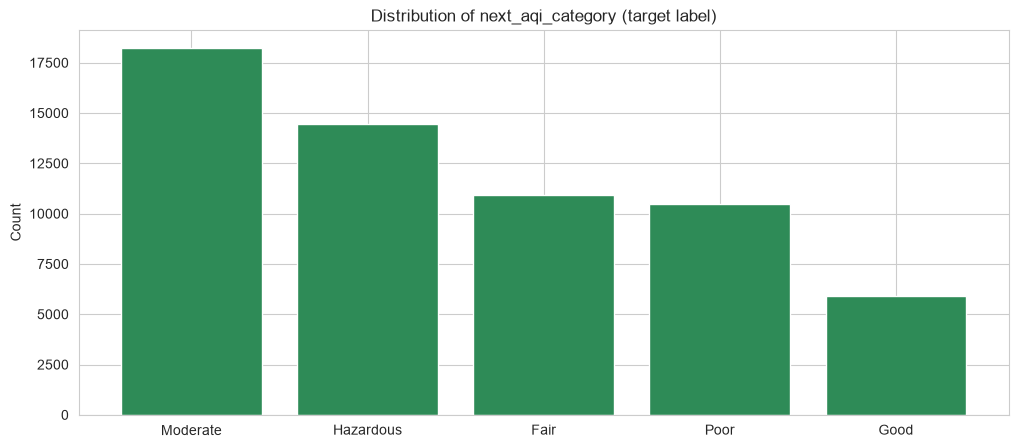

next_aqi_category
Moderate     18222
Hazardous    14439
Fair         10915
Poor         10495
Good          5890
Name: count, dtype: int64

In [10]:
label_counts = df["next_aqi_category"].value_counts()

plt.bar(label_counts.index, label_counts.values, color="seagreen")
plt.title("Distribution of next_aqi_category (target label)")
plt.ylabel("Count")
plt.show()

label_counts

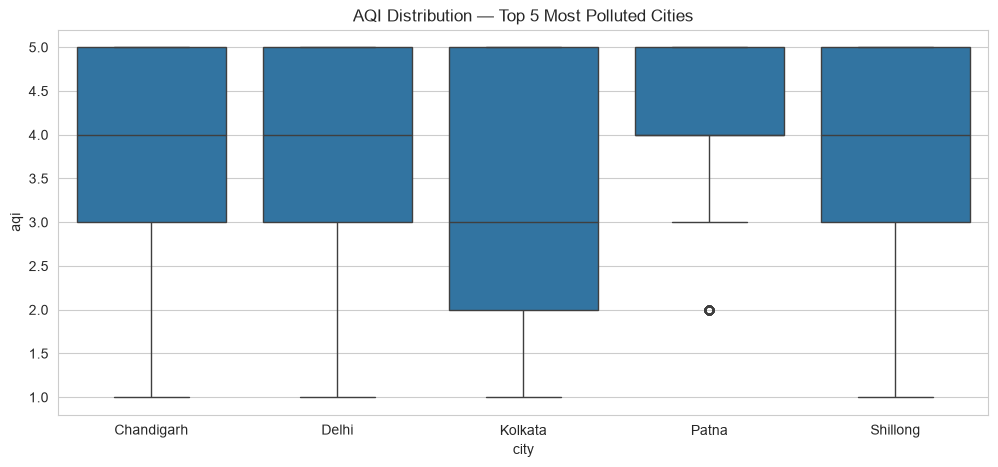

In [11]:
top5 = city_avg.head(5).index.tolist()

sns.boxplot(data=df[df["city"].isin(top5)], x="city", y="aqi")
plt.title("AQI Distribution — Top 5 Most Polluted Cities")
plt.show()

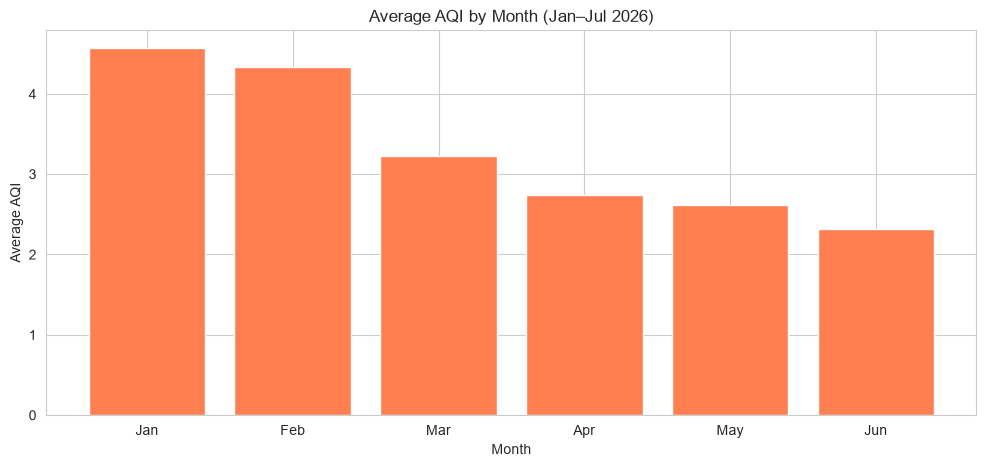

Jan    4.563837
Feb    4.334778
Mar    3.225552
Apr    2.736398
May    2.616923
Jun    2.319975
Name: aqi, dtype: float64

In [12]:
monthly_avg = df.groupby("month")["aqi"].mean()

month_names = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun", 7:"Jul"}
monthly_avg.index = [month_names.get(m, str(m)) for m in monthly_avg.index]

plt.bar(monthly_avg.index, monthly_avg.values, color="coral")
plt.title("Average AQI by Month (Jan–Jul 2026)")
plt.ylabel("Average AQI")
plt.xlabel("Month")
plt.show()

monthly_avg

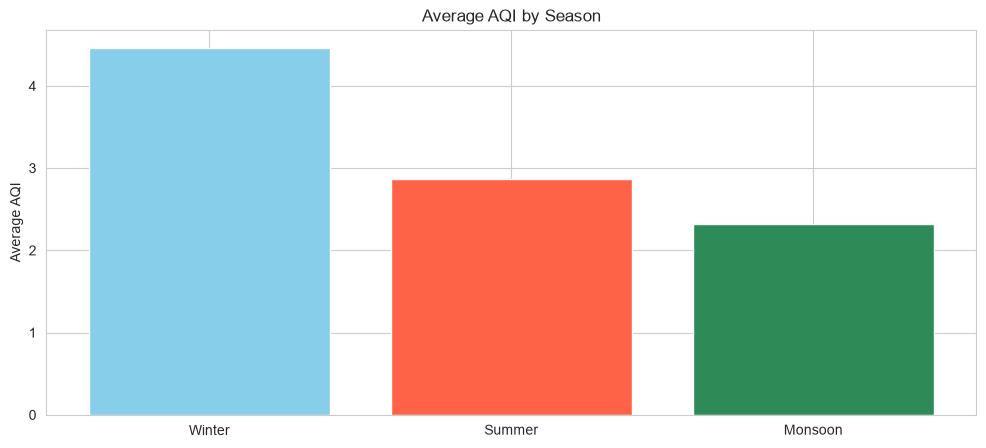

season
Winter     4.457709
Summer     2.862719
Monsoon    2.319975
Name: aqi, dtype: float64

In [13]:
def label_season(month):
    if month in [12, 1, 2]:   return "Winter"
    elif month in [3, 4, 5]:  return "Summer"
    elif month in [6, 7]:     return "Monsoon"
    else:                      return "Post-Monsoon"

df["season"] = df["month"].apply(label_season)

season_avg = df.groupby("season")["aqi"].mean().sort_values(ascending=False)

plt.bar(season_avg.index, season_avg.values, 
        color=["skyblue", "tomato", "seagreen", "orange"])
plt.title("Average AQI by Season")
plt.ylabel("Average AQI")
plt.show()

season_avg

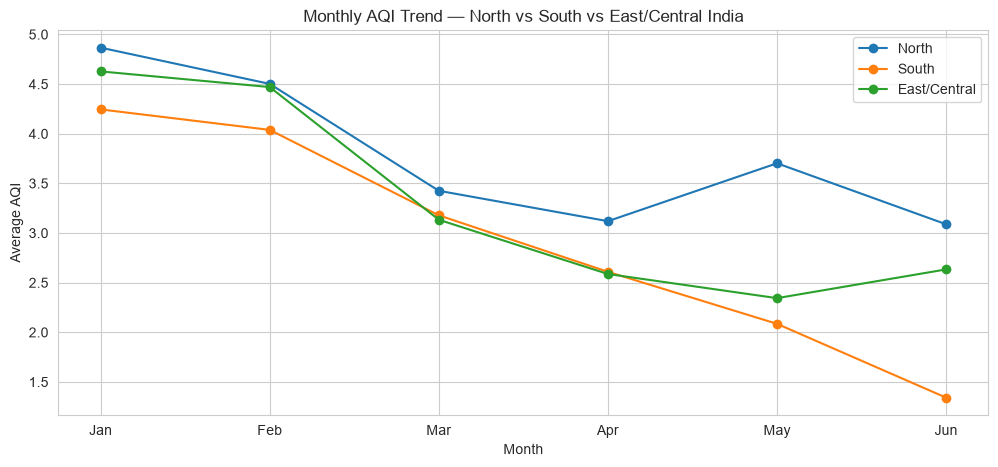

In [14]:
north = ["Delhi", "Patna", "Lucknow", "Chandigarh", "Jaipur"]
south = ["Chennai", "Bengaluru", "Hyderabad", "Mumbai", "Pune"]

df["region"] = df["city"].apply(
    lambda x: "North" if x in north else ("South" if x in south else "East/Central")
)

region_monthly = df.groupby(["region", "month"])["aqi"].mean().reset_index()
month_names_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul"}
region_monthly["month_name"] = region_monthly["month"].map(month_names_map)

for region in ["North", "South", "East/Central"]:
    subset = region_monthly[region_monthly["region"] == region]
    plt.plot(subset["month_name"], subset["aqi"], marker="o", label=region)

plt.title("Monthly AQI Trend — North vs South vs East/Central India")
plt.ylabel("Average AQI")
plt.xlabel("Month")
plt.legend()
plt.show()

Average AQI during monsoon months (Jun–Jul)  : 2.32
Average AQI during non-monsoon months         : 3.48
Average rainfall during monsoon (mm/hr)       : 0.149
Average rainfall during non-monsoon (mm/hr)   : 0.045


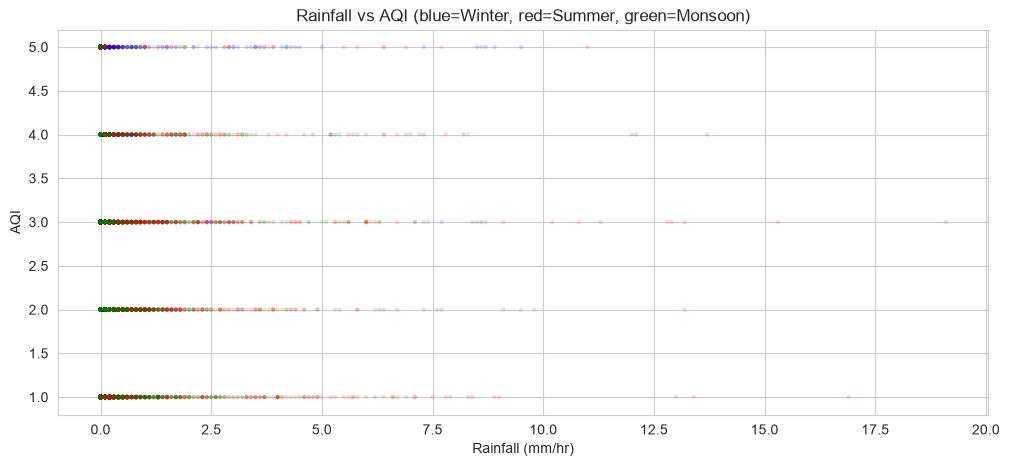

In [15]:
monsoon_months = df[df["month"].isin([6, 7])]
non_monsoon    = df[df["month"].isin([1, 2, 3, 4, 5])]

print(f"Average AQI during monsoon months (Jun–Jul)  : {monsoon_months['aqi'].mean():.2f}")
print(f"Average AQI during non-monsoon months         : {non_monsoon['aqi'].mean():.2f}")
print(f"Average rainfall during monsoon (mm/hr)       : {monsoon_months['rainfall_1h_mm'].mean():.3f}")
print(f"Average rainfall during non-monsoon (mm/hr)   : {non_monsoon['rainfall_1h_mm'].mean():.3f}")

# scatter: rainfall vs AQI colored by season
colors = df["season"].map({"Winter": "blue", "Summer": "red", "Monsoon": "green"})
plt.scatter(df["rainfall_1h_mm"], df["aqi"], c=colors, alpha=0.1, s=5)
plt.title("Rainfall vs AQI (blue=Winter, red=Summer, green=Monsoon)")
plt.xlabel("Rainfall (mm/hr)")
plt.ylabel("AQI")
plt.show()

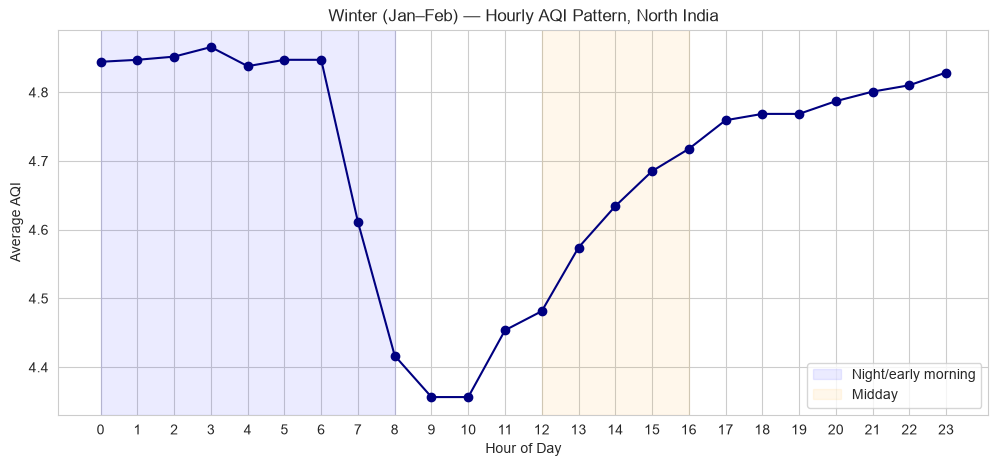

In [16]:
winter_north = df[
    (df["month"].isin([1, 2])) &
    (df["city"].isin(north))
]

winter_hourly = winter_north.groupby("hour")["aqi"].mean()

plt.plot(winter_hourly.index, winter_hourly.values, marker="o", color="navy")
plt.title("Winter (Jan–Feb) — Hourly AQI Pattern, North India")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.xticks(range(0, 24))
plt.axvspan(0, 8, alpha=0.08, color="blue", label="Night/early morning")
plt.axvspan(12, 16, alpha=0.08, color="orange", label="Midday")
plt.legend()
plt.show()